# BCS YouTube Video Analysis

This notebook searches YouTube for videos, collects public statistics, and computes monthly metrics for BCS meeting-related videos.

Note: strict historical monthly views are not available via the public YouTube Data API. This notebook uses:
- Estimated views per month from total views and publish date.
- Tracked growth per month from local snapshots collected over time.

## 1. Import Required Libraries
Import all necessary libraries and dependencies required for the project.

In [1]:
import sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

workspace_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
src_path = workspace_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from bcs_youtube.analytics import (
    add_estimated_views_per_month,
    filter_by_publisher,
    filter_by_query_terms,
    filter_meeting_videos,
    sort_for_display,
    videos_to_dataframe,
)
from bcs_youtube.config import load_config
from bcs_youtube.storage import (
    add_monthly_growth_from_snapshots,
    append_snapshot,
    load_snapshots,
)
from bcs_youtube.youtube_client import create_youtube_client, search_video_ids_for_publisher

## 2. Define Project Structure
Set up the basic project structure, including configuration variables and constants.

In [2]:
QUERY = "BCS DevSecOps Group"
PUBLISHER = "https://www.youtube.com/@BCSMemberGroups"  # Set to None to disable publisher filtering.
MAX_RESULTS = 50
EXPORT_CSV = True

DISPLAY_COLUMNS = [
    "video_id",
    "title",
    "channel_title",
    "published_at",
    "view_count",
    "like_count",
    "estimated_views_per_month",
    "tracked_views_growth_per_month",
]

config = load_config()
config

AppConfig(api_key=None, workspace_root=WindowsPath('C:/Users/royha/OneDrive/Training/Python/BCS YouTube'), snapshot_csv=WindowsPath('C:/Users/royha/OneDrive/Training/Python/BCS YouTube/data/snapshots/video_snapshots.csv'), exports_dir=WindowsPath('C:/Users/royha/OneDrive/Training/Python/BCS YouTube/data/exports'))

## 3. Initialize Core Components
Initialize the core components of the project, including any classes or functions needed.

In [4]:
client = create_youtube_client(config.api_key)
if PUBLISHER and not config.api_key:
    video_ids = search_video_ids_for_publisher(publisher=PUBLISHER, max_results=MAX_RESULTS)
    if not video_ids:
        video_ids = client.search_video_ids(query=QUERY, max_results=MAX_RESULTS)
else:
    video_ids = client.search_video_ids(query=QUERY, max_results=MAX_RESULTS)
videos = client.fetch_videos(video_ids)

raw_df = videos_to_dataframe(videos)
meeting_df = filter_by_query_terms(raw_df, query=QUERY)
meeting_df = filter_by_publisher(meeting_df, publisher=PUBLISHER)
if not PUBLISHER:
    meeting_df = filter_meeting_videos(meeting_df)
meeting_df = add_estimated_views_per_month(meeting_df)

snapshots_df = load_snapshots(config.snapshot_csv)
analysis_df = add_monthly_growth_from_snapshots(meeting_df, snapshots_df)
analysis_df = sort_for_display(analysis_df)

if not analysis_df.empty:
    display(analysis_df[DISPLAY_COLUMNS].head(30))
else:
    print("No matching videos found for the current query/publisher/filter.")

,video_id,title,channel_title,published_at,view_count,like_count,estimated_views_per_month,tracked_views_growth_per_month
0,272fLnXWaZQ,Strategic Empathy - Rehumanising Project Gover...,BCS Member Groups,2026-03-12 00:00:00+00:00,195,2,80.21,0.0
1,V_78ciCxgAQ,Deepfake Forensics: then Cybercrime Forensics ...,BCS Member Groups,2026-01-30 00:00:00+00:00,140,2,37.05,NaN
2,j8R1b8HZhwQ,"The Future of Cyber Attacks in AI Era | Beds, ...",BCS Member Groups,2026-02-10 00:00:00+00:00,109,2,31.90,NaN
3,9Li9E88sxEI,From BA to Boardroom: How a Career in Tech Can...,BCS Member Groups,2026-04-24 00:00:00+00:00,100,3,98.19,0.0
4,KUIZ2AkVJUA,Critical Thinking for Testers in the age of AI...,BCS Member Groups,2026-01-26 00:00:00+00:00,91,0,23.28,NaN
5,7cBJXpV8LL4,"Convergent Tech - AI is an Ingredient, Not a M...",BCS Member Groups,2026-02-24 00:00:00+00:00,82,0,27.73,NaN
6,jza1pDS8VCY,"AI Governance in Practice: Privacy, Vulnerabil...",BCS Member Groups,2026-01-21 00:00:00+00:00,81,0,19.88,NaN
7,yVG_Q_FKlfs,Hybrid: Build Together - Public Hackathon Show...,BCS Member Groups,2026-02-10 00:00:00+00:00,70,0,20.49,NaN
8,ibp3ZcDpxqU,Appreciating Global Regulatory Requirements fo...,BCS Member Groups,2026-02-25 00:00:00+00:00,68,3,23.26,NaN
9,NaJJqo5dqew,Using AI to Streamline Work | BCS London Branches,BCS Member Groups,2026-04-09 00:00:00+00:00,68,1,44.99,0.0


## 4. Run Basic Tests
Implement and run basic tests to verify the setup is working correctly.

In [5]:
assert isinstance(video_ids, list), "video_ids should be a list"
assert isinstance(raw_df, pd.DataFrame), "raw_df should be a DataFrame"
assert "view_count" in raw_df.columns if not raw_df.empty else True
assert "estimated_views_per_month" in analysis_df.columns if not analysis_df.empty else True
print("Basic tests passed.")

Basic tests passed.


In [6]:
append_snapshot(config.snapshot_csv, query=QUERY, df=analysis_df)
print(f"Snapshot appended to: {config.snapshot_csv}")

if EXPORT_CSV and not analysis_df.empty:
    stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
    export_file = config.exports_dir / f"youtube_analysis_{stamp}.csv"
    analysis_df.to_csv(export_file, index=False)
    print(f"Exported CSV: {export_file}")

Snapshot appended to: C:\Users\royha\OneDrive\Training\Python\BCS YouTube\data\snapshots\video_snapshots.csv
Exported CSV: C:\Users\royha\OneDrive\Training\Python\BCS YouTube\data\exports\youtube_analysis_20260525_122440.csv


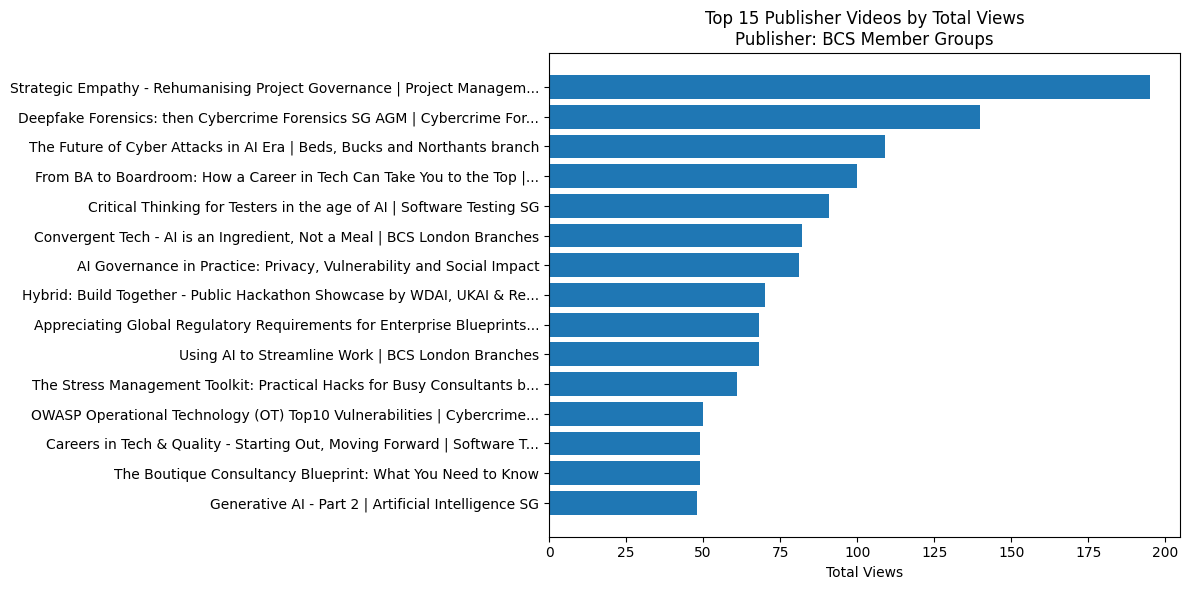

Tracked monthly growth is not available yet. Run snapshots on multiple dates.


In [10]:
def clean_label(text: str) -> str:
    # Remove non-ASCII glyphs to avoid matplotlib font warnings on Windows defaults.
    return text.encode("ascii", errors="ignore").decode("ascii").strip()

def shorten_label(text: str, max_len: int = 72) -> str:
    if len(text) <= max_len:
        return text
    return text[: max_len - 3].rstrip() + "..."

def build_plot_label(row: pd.Series) -> str:
    title = clean_label(str(row.get("title", "")))
    return shorten_label(title)

if analysis_df.empty:
    print("No data available for charts.")
else:
    top = analysis_df.head(15).copy()
    top["plot_title"] = top.apply(build_plot_label, axis=1)

    chart_scope = "Publisher" if PUBLISHER else "Meeting"
    publisher_label = ""
    if PUBLISHER and "channel_title" in analysis_df.columns and analysis_df["channel_title"].notna().any():
        publisher_label = clean_label(str(analysis_df["channel_title"].dropna().iloc[0]))

    plt.figure(figsize=(12, 6))
    plt.barh(top["plot_title"], top["view_count"])
    plt.gca().invert_yaxis()
    title = f"Top 15 {chart_scope} Videos by Total Views"
    if publisher_label:
        title += f"\nPublisher: {publisher_label}"
    plt.title(title)
    plt.xlabel("Total Views")
    plt.tight_layout()
    plt.show()

    growth = analysis_df.dropna(subset=["tracked_views_growth_per_month"]).copy()
    growth = growth[growth["tracked_views_growth_per_month"].abs() > 0]
    growth = growth.head(15)

    if growth.empty:
        print("Tracked monthly growth is not available yet. Run snapshots on multiple dates.")
    else:
        growth["plot_title"] = growth.apply(build_plot_label, axis=1)
        plt.figure(figsize=(12, 6))
        plt.barh(growth["plot_title"], growth["tracked_views_growth_per_month"])
        plt.gca().invert_yaxis()
        title = f"Tracked Views Growth Per Month ({chart_scope} Videos)"
        if publisher_label:
            title += f"\nPublisher: {publisher_label}"
        plt.title(title)
        plt.xlabel("Views / Month")
        plt.tight_layout()
        plt.show()

### Limitation Reminder
Strict historical monthly views for arbitrary public videos are not available through the public YouTube Data API.

This notebook improves accuracy over time by storing snapshots and calculating tracked growth per month from observed deltas.